In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# Function to convert ECG signals to spectrogram images in batches
def convert_to_spectrogram(data, fs=250, nperseg=128, img_size=(32, 32), batch_size=1000):
    """
    Converts a list of ECG signals to spectrogram images in batches.
    """
    spectrogram_images = []
    num_batches = (len(data) + batch_size - 1) // batch_size  # Calculate number of batches
    
    for batch_idx in range(num_batches):
        batch_data = data[batch_idx * batch_size: (batch_idx + 1) * batch_size]
        batch_spectrograms = []
        
        for idx, signal_data in enumerate(batch_data):
            # Ensure signal_data is 1D
            signal_data = np.asarray(signal_data).squeeze()
            
            # Handle short signals by padding
            if len(signal_data) < nperseg:
                signal_data = np.pad(signal_data, (0, nperseg - len(signal_data)), 'constant')
            
            # Compute spectrogram
            f, t, Sxx = spectrogram(signal_data, fs=fs, nperseg=nperseg)
            Sxx = np.log(Sxx + 1e-8)  # Log-scale for better visibility
            
            # Resize spectrogram to fixed image size
            img = cv2.resize(Sxx, img_size)
            
            # Normalize the image
            img = (img - np.mean(img)) / np.std(img)
            batch_spectrograms.append(img)
        
        spectrogram_images.append(np.array(batch_spectrograms))
        if (batch_idx + 1) % 10 == 0:
            print(f"Processed batch {batch_idx + 1} / {num_batches}")
    
    return np.concatenate(spectrogram_images)

In [3]:
# Function to load ECG data from folders and convert to spectrograms
def load_ecg_data_from_folders(root_folder, nperseg=128, visualize=False):
    all_data = []
    all_labels = []
    
    label_mapping = {'0', '1'}  # Modify based on your dataset
    
    # Traverse through the root folder and subfolders
    for subdir, dirs, files in os.walk(root_folder):
        for file in files:
            if file.endswith('.mat'):
                file_path = os.path.join(subdir, file)
                try:
                    # Load the MATLAB file
                    mat_data = loadmat(file_path)
                    if 'val' in mat_data:
                        ecg_data = mat_data['val'].squeeze()  # Squeeze to remove unnecessary dimensions
                        label = 0  # Replace with actual label extraction logic
                        all_labels.append(label)
                        all_data.append(ecg_data)
                except Exception as e:
                    print(f"Error loading MATLAB file {file_path}: {e}")

    all_data = np.array(all_data)
    all_labels = np.array(all_labels)

    # Convert ECG signals to spectrogram images
    spectrogram_images = convert_to_spectrogram(all_data, fs=250, nperseg=nperseg, img_size=(32, 32))

    return spectrogram_images, all_labels

In [4]:
# Root folder path where your .mat data is stored
root_folder = r'C:\Users\diyu2\OneDrive - AUT University\AUT YEAR 4\INDUSTRIAL PROJECT (Mechanical)\Reports Part B\ECG database-for-arrhythmia\WFDBRecords'

# Load the ECG data from folders
print("Loading ECG data and converting to spectrograms...")
data, labels = load_ecg_data_from_folders(root_folder)

# Check the shape of the data
print(f"Shape of spectrogram data: {data.shape}")
print(f"Shape of labels: {labels.shape}")

Loading ECG data and converting to spectrograms...
Processed batch 10 / 25
Processed batch 20 / 25
Shape of spectrogram data: (25000, 32, 32, 45)
Shape of labels: (25000,)


In [11]:
data = np.mean(data, axis=-1)  # Shape will now be (25000, 32, 32)

In [15]:
# Reshape for CNN: (num_samples, height, width, channels)
X_spectrograms = data.reshape(data.shape[0], 32, 32, 1)  # Add channel dimension

# Now, split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_spectrograms, labels, test_size=0.2, random_state=42, stratify=labels
)

# Check the shape of the data
print(f'Shape of training data: {X_train.shape}')
print(f'Shape of testing data: {X_test.shape}')
print(f'Shape of labels: {y_train.shape}, {y_test.shape}')

Shape of training data: (20000, 32, 32, 1)
Shape of testing data: (5000, 32, 32, 1)
Shape of labels: (20000,), (5000,)


In [16]:
# Build the CNN model
model = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(labels)), activation='sigmoid')  # Adjust for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model architecture
model.summary()

C:\Users\diyu2\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,465 (619.00 KB)

 Trainable params: 158,465 (619.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Early stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9885 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 8.2764e-13
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 1.0000 - loss: 3.8812e-11 - val_accuracy: 1.0000 - val_loss: 8.2757e-13
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 1.0000 - loss: 5.6408e-11 - val_accuracy: 1.0000 - val_loss: 8.2746e-13
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 1.0000 - loss: 3.4306e-12 - val_accuracy: 1.0000 - val_loss: 8.2745e-13
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 1.0000 - loss: 1.2178e-10 - val_accuracy: 1.0000 - val_loss: 8.2610e-13
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 1.0000 - loss: 1.2875e-11 - val_accuracy: 1.0000 - val_loss: 8.2560e-13
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 1.0000 - loss: 7.4652e-11 - val_accuracy: 1.0000 - val_loss: 8.2415e-13
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━

In [18]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')


Test Accuracy: 100.00%


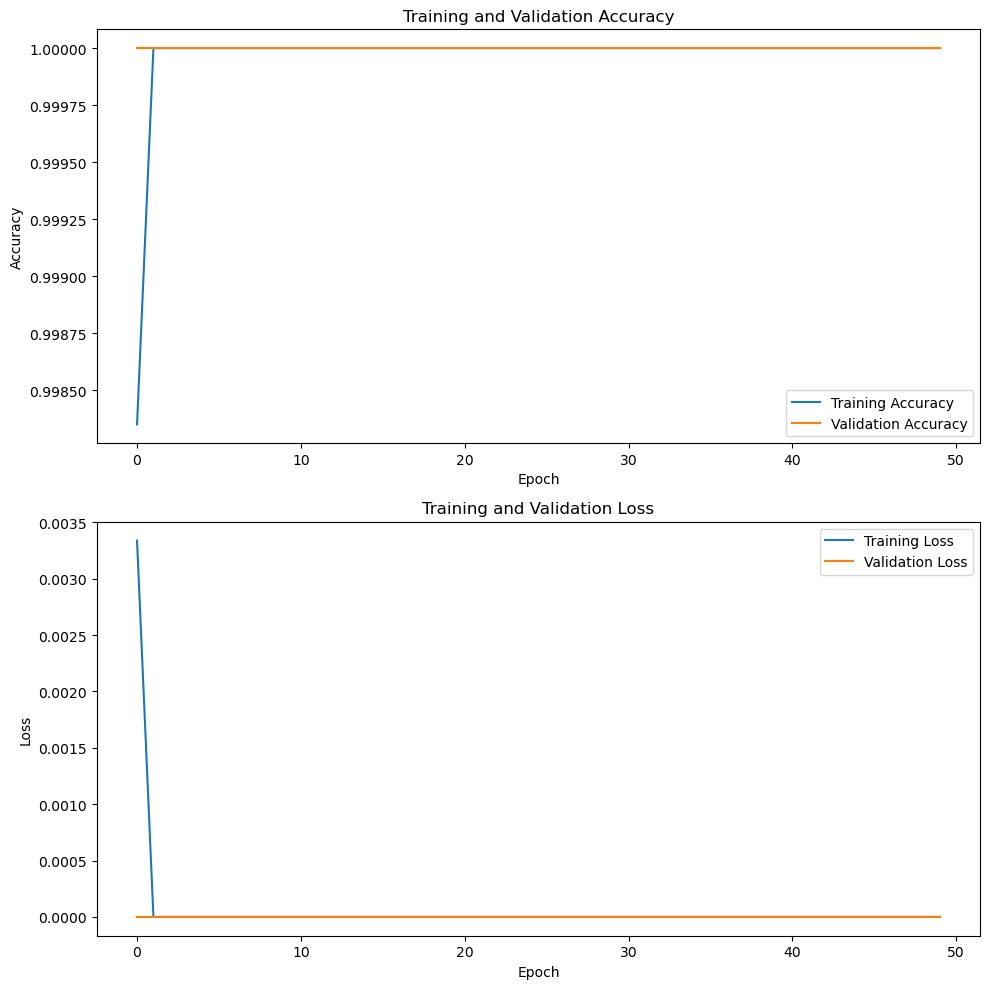

In [19]:
# Plotting the training and validation accuracy and loss
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Accuracy plot
axs[0].plot(history.history['accuracy'], label='Training Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend(loc='lower right')

# Loss plot
axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


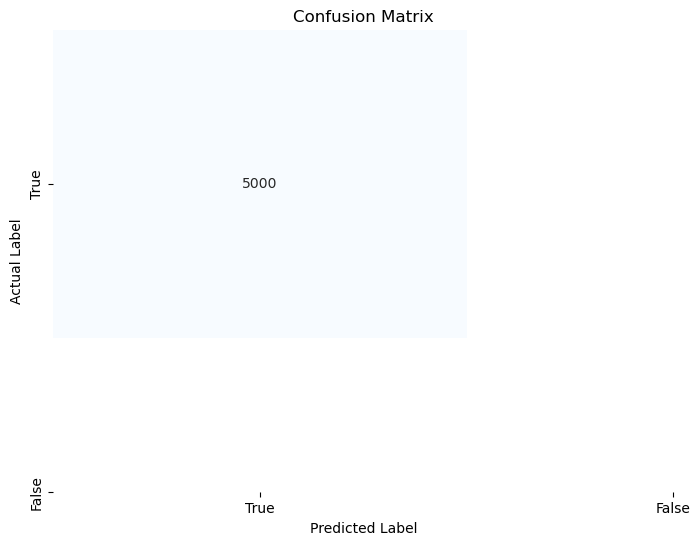

Classification Report:
              precision    recall  f1-score   support

        True       1.00      1.00      1.00      5000
       False       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       1.00      1.00      1.00      5000



In [25]:
# Predict on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion matrix plotting function
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

# Define class names based on your dataset
class_names = ['True', 'False']  # Modify based on your actual classes

# Plot confusion matrix
plot_confusion_matrix(y_test, y_pred, class_names)

# Classification report for additional metrics
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, labels=[0, 1], zero_division=0))